In [1]:
import sys
sys.executable

'/home/ksmehrab/miniconda/envs/py310/bin/python'

In [ ]:
# Use env py310
import numpy as np
import re
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from hydra import initialize, compose
import hydra
from tqdm import tqdm
import copy
import pandas as pd
from functools import reduce

"""
Set the directories
"""
img_dir = '/data/InvasivePlantsData/png-512/session_2_1_18_2025/'
molmo_save_dir = '/data/InvasivePlantsResults/MolmoUnbatchedPoints'
sam_save_dir = '/data/InvasivePlantsResults/SAMMasksUnbatched'

# Read csv and iterate thru the images 
# change this to your path containing sample image names for qualitative analysis
segmentation_test_dataset_file = 'sample_images.csv'

if not os.path.exists(sam_save_dir):
    os.mkdir(sam_save_dir)

In [11]:
required_images = list(pd.read_csv(segmentation_test_dataset_file).filename)
# Check if some of the images have already been done by checking the sam save directory
# required_images = [img_filename for img_filename in required_images if os.path.splitext(img_filename)[0]+'.npy' not in os.listdir(sam_save_dir)]

# required_images = [required_images[-1]]

"""
Set paths to the SAM2 checkpoint and config file
"""
sam2_checkpoint = "/home/ksmehrab/SAM2/sam2/checkpoints/sam2.1_hiera_large.pt"
config_dir = "./sam2.1"
model_cfg = "sam2.1_hiera_l.yaml"
# model_cfg = "./sam2.1/sam2.1_hiera_l.yaml"
hydra.core.global_hydra.GlobalHydra.instance().clear()

device='cuda'
with initialize(config_path=config_dir):
    cfg = compose(config_name=model_cfg)
    sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

/tmp/ipykernel_1038271/773941543.py:17: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_dir):


In [12]:
import numpy as np

def sample_points_around(x, y, n, r):
    """
    Sample n points uniformly around (x, y) within a circle of radius r.
    
    Returns a list of (x_i, y_i) coordinates.
    """
    angles = np.random.uniform(0, 2 * np.pi, n)
    radii = np.random.uniform(0, r, n)
    
    dx = radii * np.cos(angles)
    dy = radii * np.sin(angles)
    
    sampled_points = np.stack([x + dx, y + dy], axis=-1)
    return sampled_points


In [ ]:
def show_points(image, points, point_size=5, point_color= "#FF0000"):
    """
    Visualize and display predicted points on the image.
    
    Args:
        image: PIL Image object or path to image
        points: List of (x,y) points to visualize
        point_size: Size of the points to draw (default: 5)
        point_color: Color of points in hex format (default: red)
    """
    
    # If image is a path, load it
    if isinstance(image, str):
        image = Image.open(image).convert('RGB')
    
    # Create a copy of the image to draw on
    img_draw = image.copy()
    draw = ImageDraw.Draw(img_draw)
    
    # Draw each point as a filled circle
    for point in points:
        x, y = point
        draw.ellipse([x-point_size, y-point_size, x+point_size, y+point_size], 
                    fill=point_color)
    
    # Display the image with points
    plt.figure(figsize=(12, 8))
    plt.imshow(img_draw)
    plt.axis('off')  # Hide axes
    plt.show()


In [14]:
def show_mask(pil_img_array, mask_binary):
    plt.figure(figsize=(10, 10))

    # Plot the original image
    plt.imshow(pil_img_array)

    # # Overlay the mask with a semi-transparent red color
    # mask_plot = plt.imshow(mask_binary, alpha=0.5, cmap='plasma')

    # # Add colorbar as legend
    # cbar = plt.colorbar(mask_plot)
    # cbar.set_ticks([0, 1])
    # cbar.set_ticklabels(['Background', 'Damaged Region'])

    # Create a custom color mask
    # Using a bright color for damaged regions and transparent for background
    colored_mask = np.zeros((*mask_binary.shape, 4))  # RGBA array
    colored_mask[mask_binary == 1] = [1, 0, 0, 1]  # Red with 1 alpha for damaged regions
    colored_mask[mask_binary == 0] = [0, 0, 0, 0]    # Transparent for background

    # Plot the colored mask
    plt.imshow(colored_mask)

    # Create custom legend patches
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=1, label='Damaged Region'),
        Patch(facecolor='white', alpha=0, label='Background')
    ]
    plt.legend(handles=legend_elements, loc='upper right', framealpha=1)

    # Remove axes for cleaner visualization
    plt.axis('off')

    # Show the plot
    plt.show()


In [23]:
def show_img(pil_img):
    plt.figure(figsize=(10, 10))
    plt.imshow(pil_img)
    plt.axis('off')
    plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

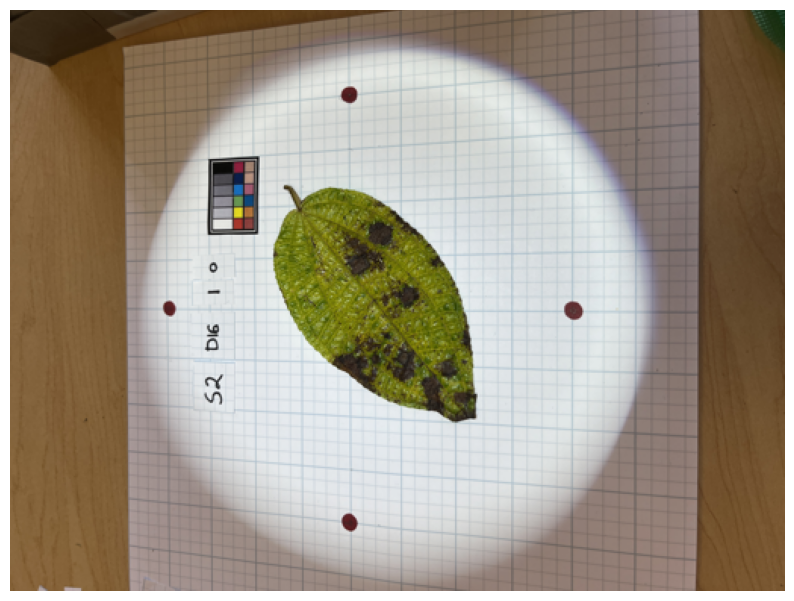

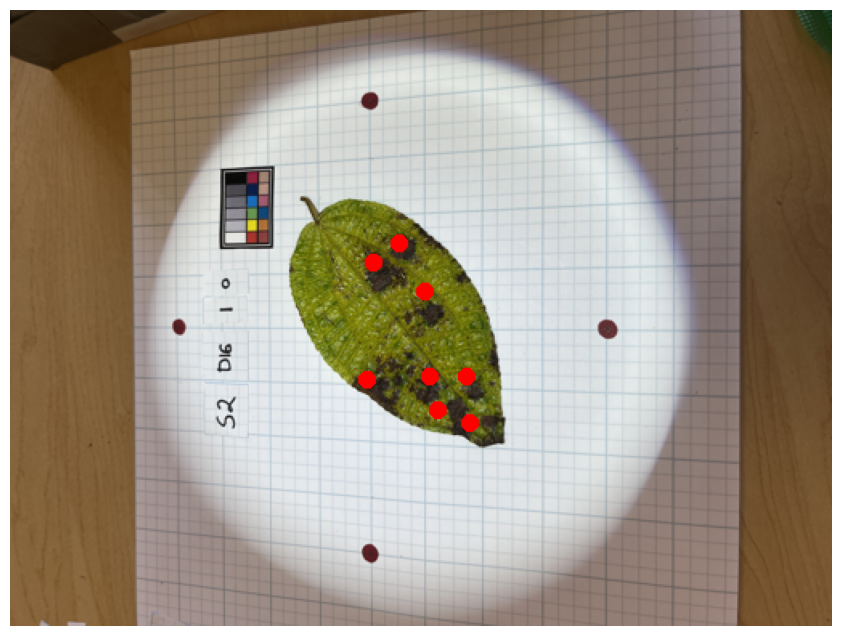

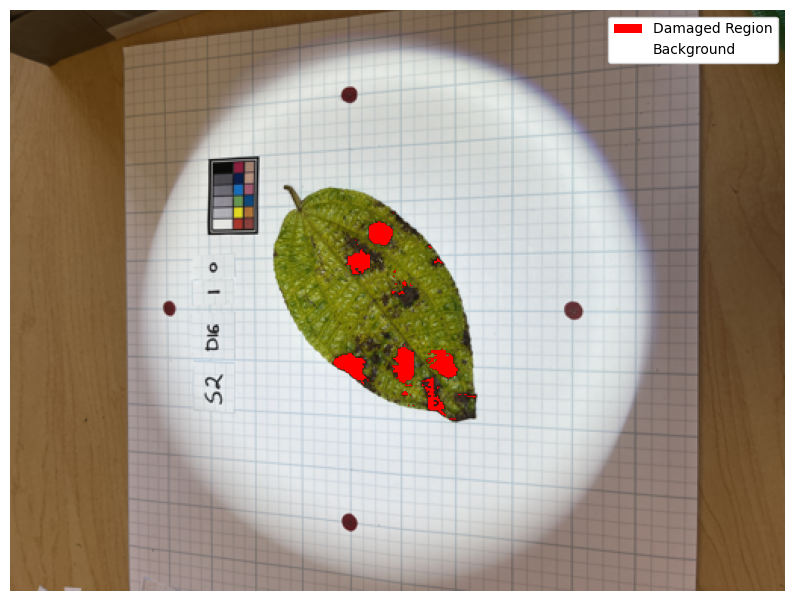

 20%|██        | 1/5 [00:01<00:05,  1.43s/it]

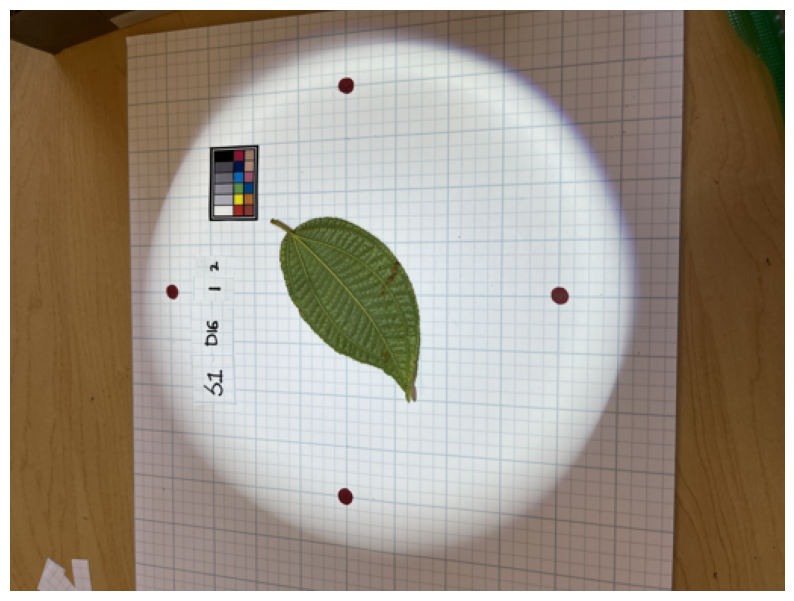

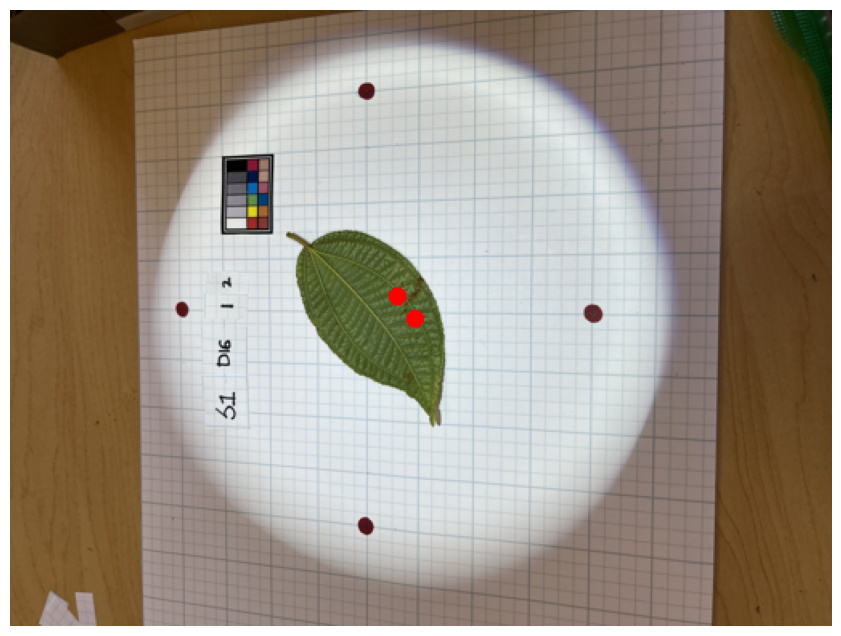

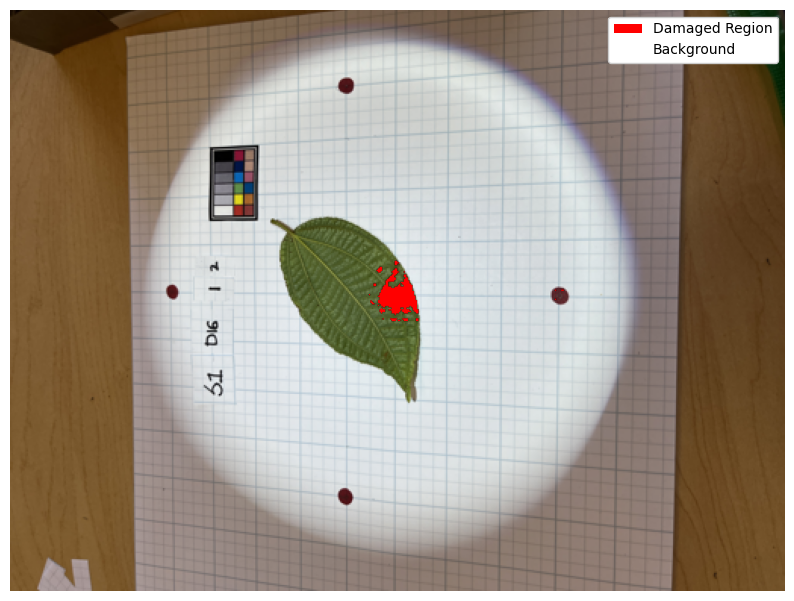

 40%|████      | 2/5 [00:02<00:03,  1.03s/it]

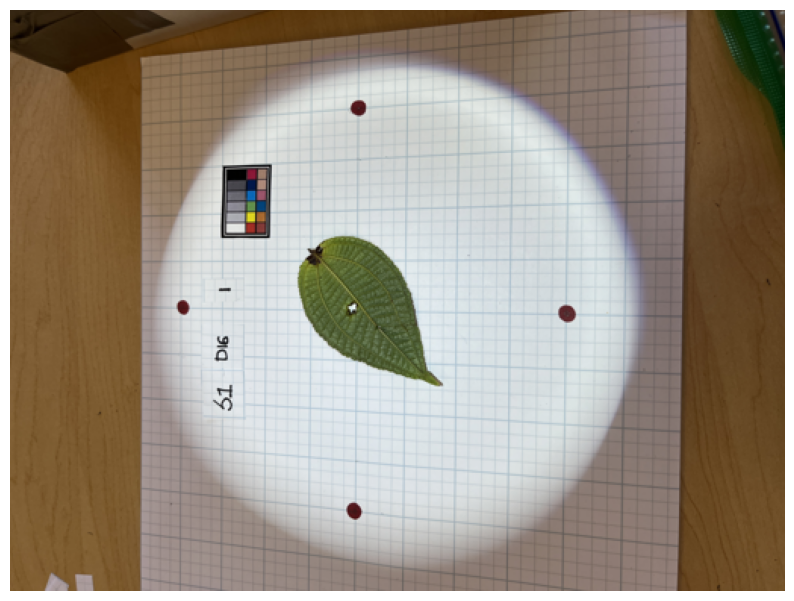

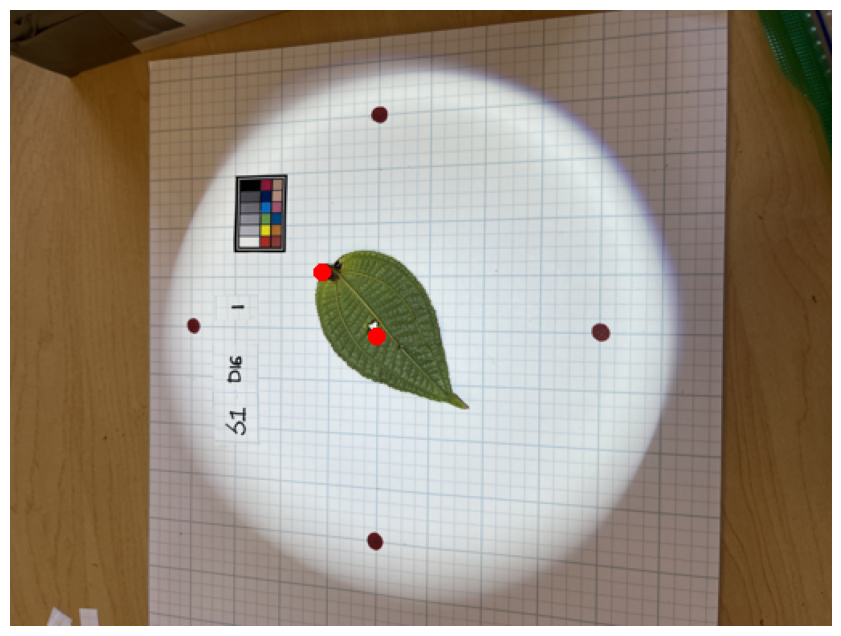

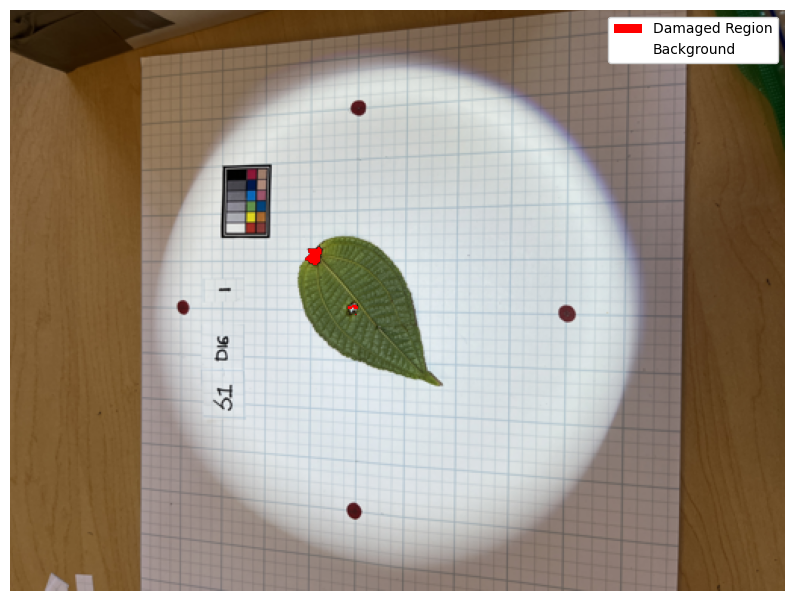

 60%|██████    | 3/5 [00:02<00:01,  1.10it/s]

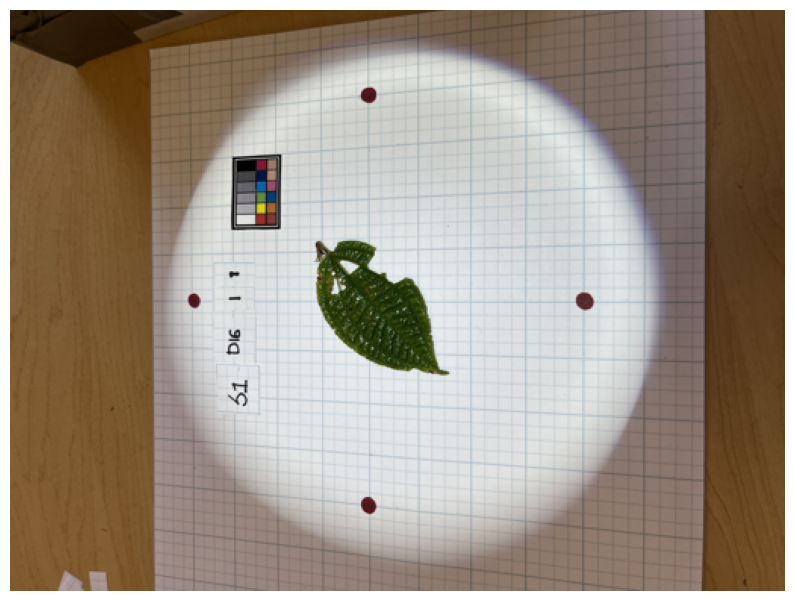

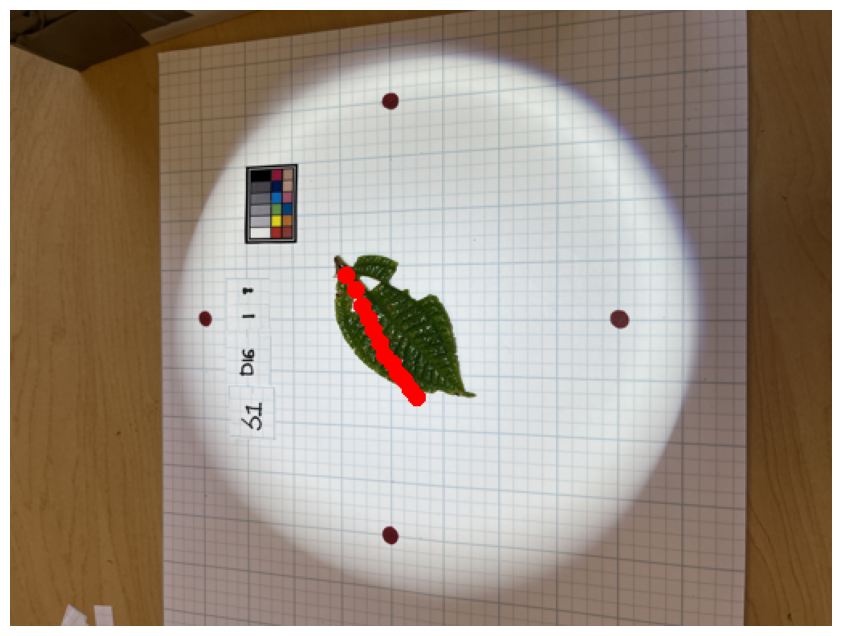

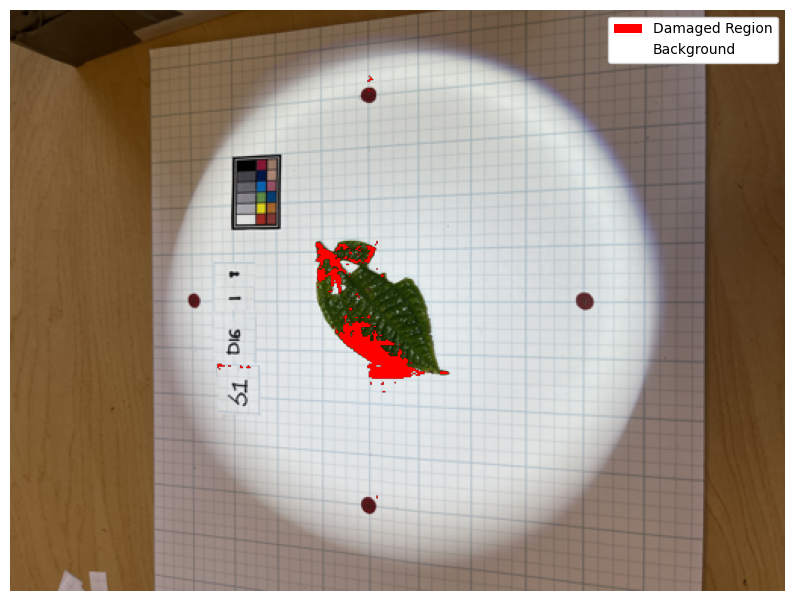

 80%|████████  | 4/5 [00:04<00:01,  1.29s/it]

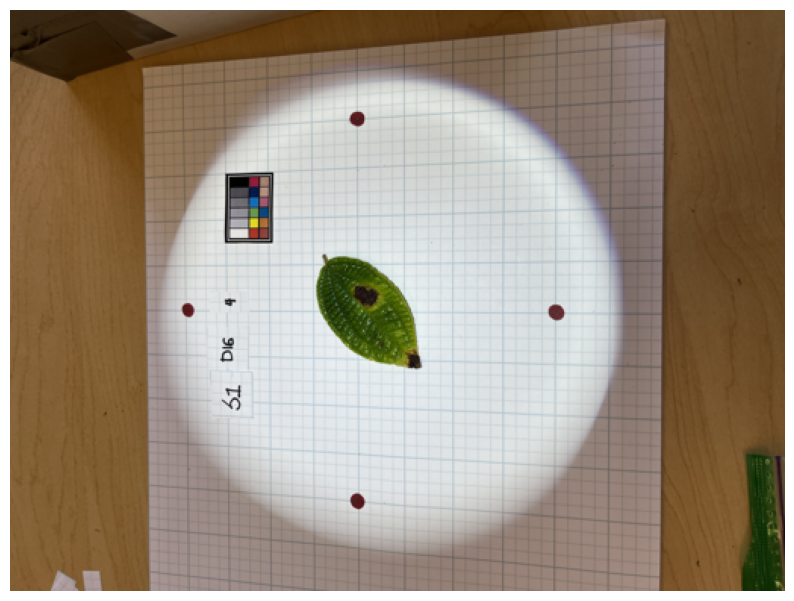

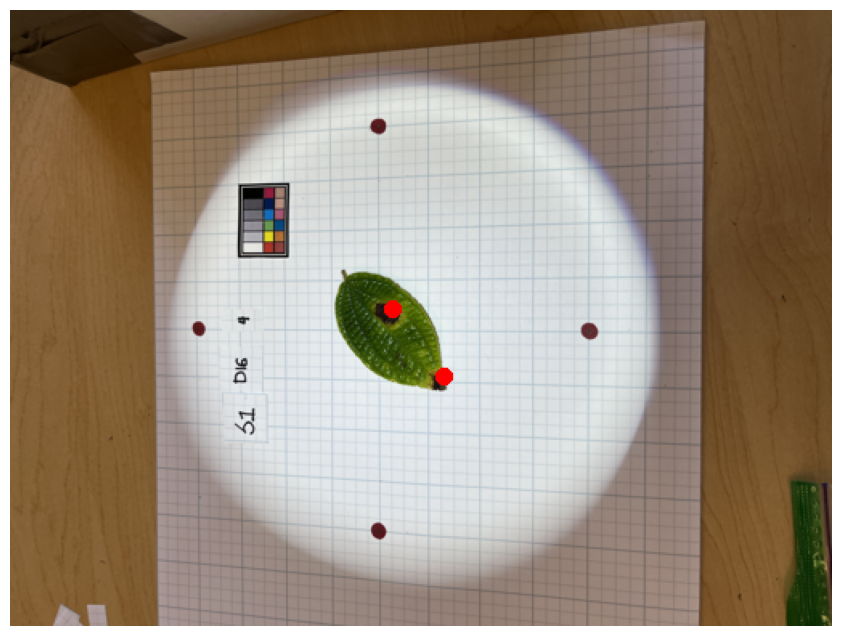

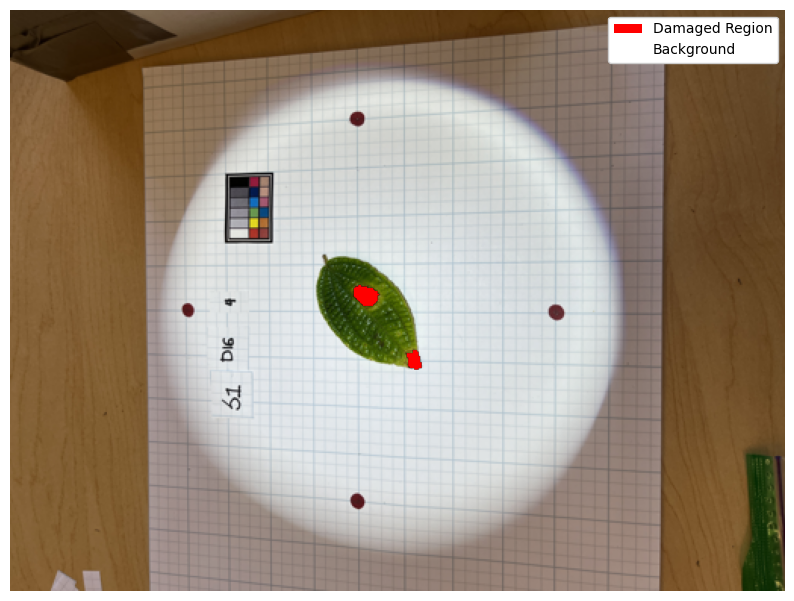

100%|██████████| 5/5 [00:05<00:00,  1.12s/it]

In [ ]:
for img_filename in tqdm(required_images):
    img_path = os.path.join(img_dir, img_filename)
    pil_img = Image.open(img_path).convert('RGB')
    pil_img_array = np.asarray(pil_img)

    npy_filename = os.path.splitext(img_filename)[0]+'.npy'
    points_dict = np.load(os.path.join(molmo_save_dir, npy_filename), allow_pickle=True).item()
    points = points_dict['damaged_regions']
    
    all_masks = []
    for point in points:
    
        sampled_positive_points = sample_points_around(point[0], point[1], 5, 5)
        sam_input_points = np.array(sampled_positive_points)

        sampled_negative_points = sample_points_around(point[0], point[1], 50, 50)
        sam_input_points = np.concatenate((sam_input_points, sampled_negative_points), axis=0)

        # print(sam_input_points)

        # sam_input_points = np.array([point])

        point_labels = np.array([1] * len(sampled_positive_points) + [0] * len(sampled_negative_points)) 

        predictor.set_image(pil_img_array)

        masks, scores, _ = predictor.predict(
            point_coords=sam_input_points,
            point_labels=point_labels,
            multimask_output=False
        ) 
        
        mask_binary = masks[0].astype(int)
        all_masks.append(mask_binary)
        # Create a figure with a specific size
        
    masks_combined = reduce(lambda x, y: x | y, all_masks)
    show_img(pil_img)
    show_points(pil_img, points)
    show_mask(pil_img_array, masks_combined)

    # optionally save the masks to sam_save_dir. not implemented here

    print("==========================")

